# CNN Inference: Load Trained Model + Test on Real Photos

Small, focused notebook, only loads the trained CNN (checkpoint
`best_model_cnn.pt`, produced by `03A_cnn_from_scratch_class.ipynb`) and
runs predictions on real photos. No training code mixed in, mirrors the
structure of `04B_vit_inference_colab.ipynb` for the ViT.

**Run the cells in order, top to bottom, every time you open a new
session.**

## 0. Environment setup

In [1]:
#  ENVIRONMENT SETUP 
RUNTIME = "local"     # "colab" or "local"
DEVICE  = "auto"      # "auto", "gpu", or "cpu"

In [2]:
import torch

if RUNTIME == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q torch torchvision

    PROJECT_ROOT = "/content/drive/MyDrive/CNN/wardrove-selector"
elif RUNTIME == "local":
    PROJECT_ROOT = ".."
else:
    raise ValueError(f"Unknown RUNTIME: {RUNTIME!r} (expected 'colab' or 'local')")

import sys
sys.path.append(f"{PROJECT_ROOT}/src")

if DEVICE == "auto":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif DEVICE == "gpu":
    if not torch.cuda.is_available():
        raise RuntimeError("DEVICE='gpu' was requested but no GPU is available in this runtime.")
    device = torch.device('cuda')
elif DEVICE == "cpu":
    device = torch.device('cpu')
else:
    raise ValueError(f"Unknown DEVICE: {DEVICE!r} (expected 'auto', 'gpu', or 'cpu')")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"device       = {device}")

PROJECT_ROOT = ..
device       = cpu


## 1. Load the architecture

In [3]:
from model import GarmentCNN

model = GarmentCNN(num_classes=14)

## 2. Load the trained weights

`GarmentCNN()` alone gives you an **untrained** model (random weights),
this cell loads the actual weights from training. Skip it and predictions
will be close to random.

In [4]:
model.load_state_dict(torch.load(
    f"{PROJECT_ROOT}/notebooks/best_model_cnn.pt",
    map_location=device   # works even if the checkpoint was saved on a different device (cpu/gpu) than this one
))

model = model.to(device)
model.eval()

print("Checkpoint loaded, model ready on:", device)

Checkpoint loaded, model ready on: cpu


## 3. Categories

Same fixed order as `src/data.py` (`label_to_val`), must match, since
the model's output index N means "class N in this exact list".

In [5]:
categories = ["Tshirts","Shirts","Tops","Jeans","Sweatshirts","Sweaters",
      "Jackets","Dresses","Skirts","Shorts","Track Pants",
      "Casual Shoes","Sports Shoes","Formal Shoes"]

## 4. Prediction function

Uses the same preprocessing the CNN was trained/evaluated with (resize +
tensor conversion, no extra normalization, see `src/data.py`'s
`eval_transform`). Unlike the ViT, this model does **not** use a
HuggingFace `processor`, using the wrong preprocessing here would
silently give nonsense predictions, exactly like the bug we hit and fixed
on the ViT side.

In [6]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def image_predict_cnn(image, filename=""):
    image_tensor = eval_transform(image).unsqueeze(0)   # add the batch dimension the model expects

    with torch.no_grad():
        logits = model(image_tensor.to(device))
        pred = torch.argmax(logits, dim=1)

    print(f"{filename}: {categories[pred.item()]}")

    plt.imshow(image)
    plt.axis('off')
    plt.show()

## 5. Run over every photo in `data/my_photos/`

Automatically picks up every `.jpg`/`.JPG` in the folder, no need to
list filenames by hand.

Found 10 photos
photo_01.jpg: Shirts


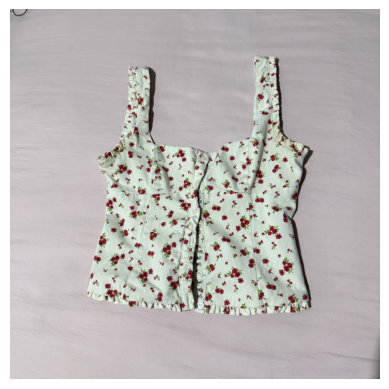

photo_02.jpg: Tshirts


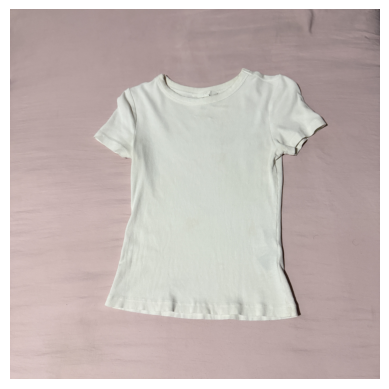

photo_03.jpg: Jeans


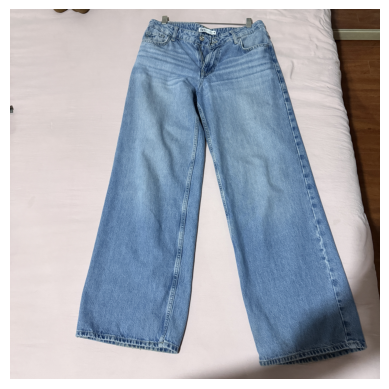

photo_04.jpg: Skirts


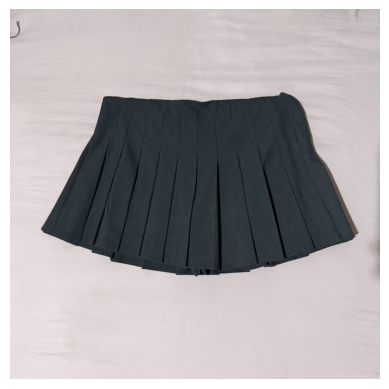

photo_05.jpg: Casual Shoes


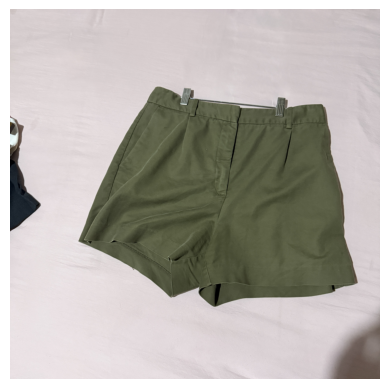

photo_G01.jpg: Shirts


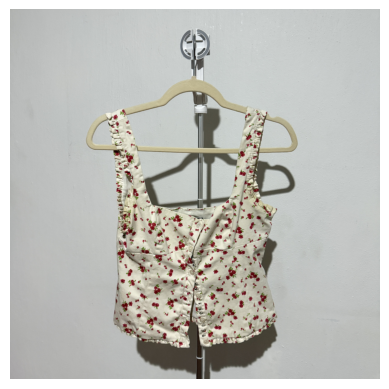

photo_G02.jpg: Shirts


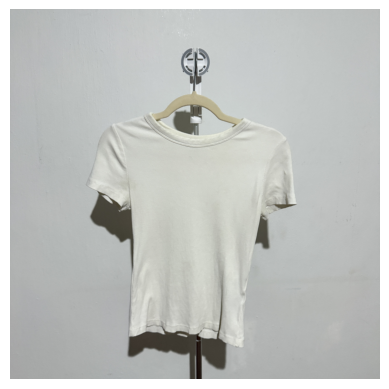

photo_G03.jpg: Shirts


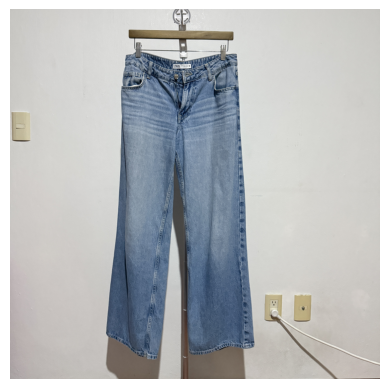

photo_G04.jpg: Shirts


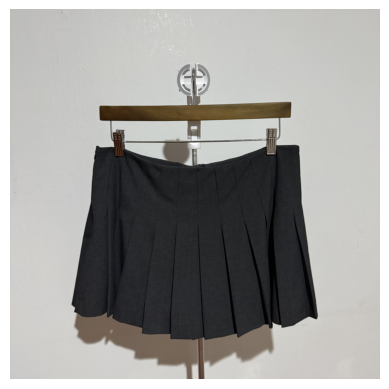

photo_G05.jpg: Shirts


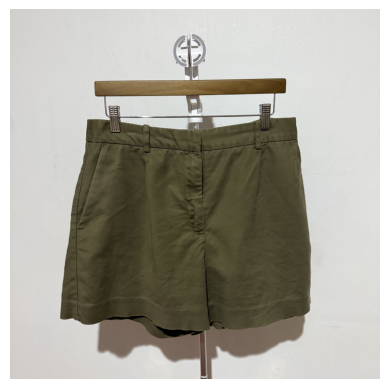

In [7]:
from pathlib import Path

photos_dir = Path(f"{PROJECT_ROOT}/data/my_photos")
photo_paths = sorted(photos_dir.glob("*.jpg")) + sorted(photos_dir.glob("*.JPG"))

print(f"Found {len(photo_paths)} photos")

for path in photo_paths:
    image = Image.open(path).convert("RGB")
    image_predict_cnn(image, filename=path.name)